In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

import tensorflow as tf
import matplotlib.pyplot as plt

from src.config import TRAIN_DIR, VAL_DIR, TEST_DIR
from src.dataset import load_train_val_test_datasets, optimize_dataset
from src.train_cnn import build_cnn_baseline
from src.utils import print_class_distribution

In [2]:
print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU devices: []


In [3]:
print("Train dir:", TRAIN_DIR)
print("Val dir:", VAL_DIR)
print("Test dir:", TEST_DIR)

print("Train exists:", TRAIN_DIR.exists())
print("Val exists:", VAL_DIR.exists())
print("Test exists:", TEST_DIR.exists())

Train dir: D:\School\traffic-sign-recognition\data\processed\train
Val dir: D:\School\traffic-sign-recognition\data\processed\val
Test dir: D:\School\traffic-sign-recognition\data\processed\test
Train exists: True
Val exists: True
Test exists: True


In [4]:
train_counts = print_class_distribution(TRAIN_DIR)
val_counts = print_class_distribution(VAL_DIR)
test_counts = print_class_distribution(TEST_DIR)

Dataset folder: D:\School\traffic-sign-recognition\data\processed\train
--------------------------------------------------
0: 168
1: 1776
10: 1608
11: 1056
12: 1680
13: 1728
14: 624
15: 504
16: 336
17: 888
18: 960
19: 168
2: 1800
20: 288
21: 264
22: 312
23: 408
24: 216
25: 1200
26: 480
27: 192
28: 432
29: 216
3: 1128
30: 360
31: 624
32: 192
33: 551
34: 336
35: 960
36: 312
37: 168
38: 1656
39: 240
4: 1584
40: 288
41: 192
42: 192
5: 1488
6: 336
7: 1152
8: 1128
9: 1176
--------------------------------------------------
Total images: 31367
Dataset folder: D:\School\traffic-sign-recognition\data\processed\val
--------------------------------------------------
0: 42
1: 444
10: 402
11: 264
12: 420
13: 432
14: 156
15: 126
16: 84
17: 222
18: 240
19: 42
2: 450
20: 72
21: 66
22: 78
23: 102
24: 54
25: 300
26: 120
27: 48
28: 108
29: 54
3: 282
30: 90
31: 156
32: 48
33: 138
34: 84
35: 240
36: 78
37: 42
38: 414
39: 60
4: 396
40: 72
41: 48
42: 48
5: 372
6: 84
7: 288
8: 282
9: 294
----------------------

In [5]:
train_ds, val_ds, test_ds, class_names = load_train_val_test_datasets()

num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Found 31367 files belonging to 43 classes.
Found 7842 files belonging to 43 classes.
Found 12630 files belonging to 43 classes.
Class names: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']
Number of classes: 43


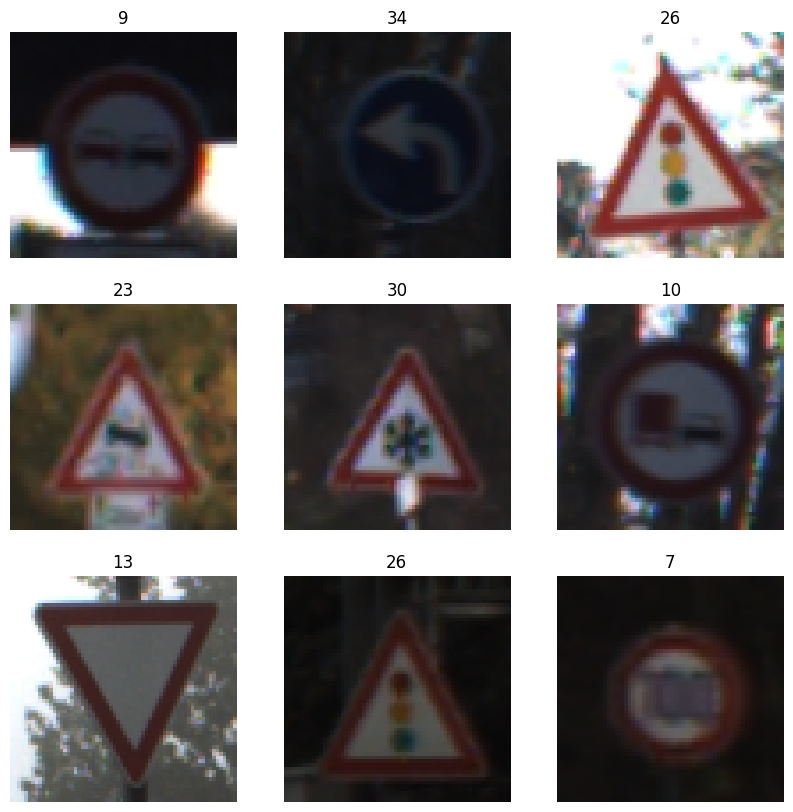

In [6]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [7]:
train_ds = optimize_dataset(train_ds)
val_ds = optimize_dataset(val_ds)
test_ds = optimize_dataset(test_ds)

In [8]:
model = build_cnn_baseline(num_classes)

model.summary()

Model: "cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         2,795 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,539 (119.29 KB)

 Trainable params: 30,539 (119.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
for images, labels in train_ds.take(1):
    predictions = model(images)
    print("Input batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Prediction shape:", predictions.shape)
    print("Example prediction:", predictions[0])
    break

Input batch shape: (16, 64, 64, 3)
Label batch shape: (16,)
Prediction shape: (16, 43)
Example prediction: tf.Tensor(
[0.02377162 0.02106589 0.02323993 0.02347878 0.02254413 0.02356606
 0.02568388 0.02111201 0.02326031 0.02362747 0.02309372 0.02268483
 0.02483602 0.02324822 0.02163093 0.02376415 0.02326573 0.02507725
 0.02461069 0.02413115 0.02374906 0.02365485 0.02507179 0.02291888
 0.02358389 0.02392814 0.02255043 0.02159765 0.02197441 0.02315597
 0.02171027 0.02403278 0.02312148 0.02398925 0.0227292  0.02373177
 0.02326397 0.02150368 0.02362382 0.02456163 0.02392037 0.02146139
 0.02247254], shape=(43,), dtype=float32)


In [10]:
small_train_ds = train_ds.take(20)
small_val_ds = val_ds.take(5)

history = model.fit(
    small_train_ds,
    validation_data=small_val_ds,
    epochs=1
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.0437 - loss: 3.7481 - val_accuracy: 0.0000e+00 - val_loss: 3.9127


In [11]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

PROJECT_ROOT: d:\School\traffic-sign-recognition
src exists: True


In [12]:
from src.train_cnn import train_cnn_model
from src.config import CNN_MODEL_PATH, CNN_HISTORY_FIGURE_PATH

Epoch 1/10
298/300 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0518 - loss: 3.6322
Epoch 1: val_accuracy improved from None to 0.26406, saving model to D:\School\traffic-sign-recognition\models\cnn_baseline.keras

Epoch 1: finished saving model to D:\School\traffic-sign-recognition\models\cnn_baseline.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.0592 - loss: 3.5542 - val_accuracy: 0.2641 - val_loss: 3.1001
Epoch 2/10
298/300 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0998 - loss: 3.3147
Epoch 2: val_accuracy did not improve from 0.26406
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.1077 - loss: 3.2416 - val_accuracy: 0.2391 - val_loss: 3.0044
Epoch 3/10
299/300 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1191 - loss: 3.1214
Epoch 3: val_accuracy improved from 0.26406 to 0.33203, saving model to D:\School\traffic-sign-recognition\models\cnn_baseline.keras

Epoch 3: finished saving model to D:\School\traffic-sign-recognition\models\cnn_baseline.ke

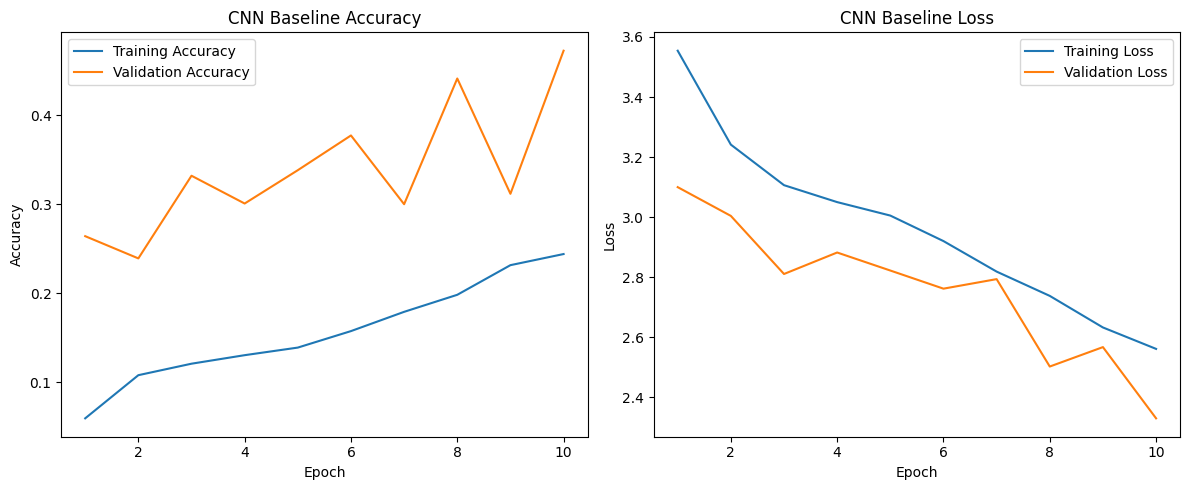

Training history figure saved to: D:\School\traffic-sign-recognition\results\figures\cnn_accuracy_loss.png


In [13]:
train_ds_for_week2 = train_ds.take(300)
val_ds_for_week2 = val_ds.take(80)

EPOCHS = 10

cnn_model, cnn_history = train_cnn_model(
    train_ds=train_ds_for_week2,
    val_ds=val_ds_for_week2,
    num_classes=num_classes,
    epochs=EPOCHS
)

In [14]:
print("CNN model path:", CNN_MODEL_PATH)
print("Model exists:", CNN_MODEL_PATH.exists())

print("Training figure path:", CNN_HISTORY_FIGURE_PATH)
print("Figure exists:", CNN_HISTORY_FIGURE_PATH.exists())

CNN model path: D:\School\traffic-sign-recognition\models\cnn_baseline.keras
Model exists: True
Training figure path: D:\School\traffic-sign-recognition\results\figures\cnn_accuracy_loss.png
Figure exists: True


In [15]:
small_test_ds = test_ds.take(100)

test_loss, test_accuracy = cnn_model.evaluate(small_test_ds)

print("Small test loss:", test_loss)
print("Small test accuracy:", test_accuracy)

100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4544 - loss: 2.3551
Small test loss: 2.355081081390381
Small test accuracy: 0.4543749988079071
